In [1]:
import ccdproc
from os import listdir
from astropy.io import fits
import glob
import pylab
from astropy.table import Table
import numpy as np 
import ccdproc as cp 
from glob import glob
import matplotlib.pyplot as plt
from ccdproc import *   
import astropy.units as u
import os
from glob import glob
import glob
import math 

In [2]:
# def subtract_fits_images(imageA_path, imageB_path, output_path='C.fit'):
#     """
#     将两个FITS图像相减：A - B = C
    
#     参数:
#     imageA_path: A.fits文件路径
#     imageB_path: B.fits文件路径  
#     output_path: 输出文件路径，默认为C.fits
#     """
    
#     # 检查文件是否存在
#     if not os.path.exists(imageA_path):
#         print(f"错误: 文件 {imageA_path} 不存在")
#         return
#     if not os.path.exists(imageB_path):
#         print(f"错误: 文件 {imageB_path} 不存在")
#         return
    
    # try:
    #     # 读取A图像
    #     with fits.open(imageA_path) as hdul_A:
    #         data_A = hdul_A[0].data.astype(np.float32)
    #         header_A = hdul_A[0].header.copy()
        
    #     # 读取B图像
    #     with fits.open(imageB_path) as hdul_B:
    #         data_B = hdul_B[0].data.astype(np.float32)
        
    #     # 检查图像尺寸是否匹配
    #     if data_A.shape != data_B.shape:
    #         print(f"错误: 图像尺寸不匹配")
    #         print(f"A图像尺寸: {data_A.shape}")
    #         print(f"B图像尺寸: {data_B.shape}")
    #         return
        
    #     # 执行减法：A - B
    #     result_data = data_A - data_B
        
    #     # 更新头信息
    #     #header_A['HISTORY'] = f'图像减法: {os.path.basename(imageA_path)} - {os.path.basename(imageB_path)}'
    #     #header_A['OPERATION'] = 'SUBTRACTION'
    #     #header_A['INPUT_A'] = (os.path.basename(imageA_path), '被减数图像')
    #     #header_A['INPUT_B'] = (os.path.basename(imageB_path), '减数图像')
        
    #     # 创建新的HDU并保存
    #     new_hdu = fits.PrimaryHDU(data=result_data, header=header_A)
    #     new_hdu.writeto(output_path, overwrite=True)
        
    #     # 打印成功信息
    #     print("图像减法完成!")
    #     print(f"输入文件A: {imageA_path}")
    #     print(f"输入文件B: {imageB_path}")
    #     print(f"输出文件: {output_path}")
    #     print(f"输入图像A尺寸: {data_A.shape}")
    #     print(f"输入图像B尺寸: {data_B.shape}")
    #     print(f"输出图像尺寸: {result_data.shape}")
    #     print(f"结果数据范围: {np.min(result_data):.2f} 到 {np.max(result_data):.2f}")
        
    # except Exception as e:
    #     print(f"处理过程中发生错误: {e}")


In [3]:
# subtract_fits_images('HIP19139-g80o50-0001-100ms.fit', 'dark-g80o50-0004-100ms.fit', 'HIP19139-g80o50-0001-100ms-subdark.fit')

In [4]:
# def takemean( path ):
#     fh=fits.open(path)     
#     return  fh[0].data[1050:1106,930:964].mean()

def takestat( path ):
    fh=fits.open(path)
     
        
    #return fh[0].header["EXPTIME"], fh[0].data[644:1140,860:1110].sum()   ### 取总和   要尽量大 覆盖到
    return fh[0].header["EXPTIME"], fh[0].data[644:1140,960:1120].sum()   ### 取总和   要尽量大 覆盖到
     

 
def takestd( path ):
    fh=fits.open(path)
    #return  fh[0].data[650:1130,910:1150].std()
    return  fh[0].data[850:950,1040:1060].std()
    
 

exptime
-------
   0.01
   0.04
    0.1
    0.2
   0.01
   0.04
    0.1
    0.2
   0.01
   0.04
    0.1
    0.2
      count       
------------------
50965676.800000004
       206409700.8
       557348064.0
1077566937.6000001
        55607564.8
       206558468.8
       552606192.0
      1050466457.6
        51932252.0
       206919104.0
       543928384.0
      1076362496.0


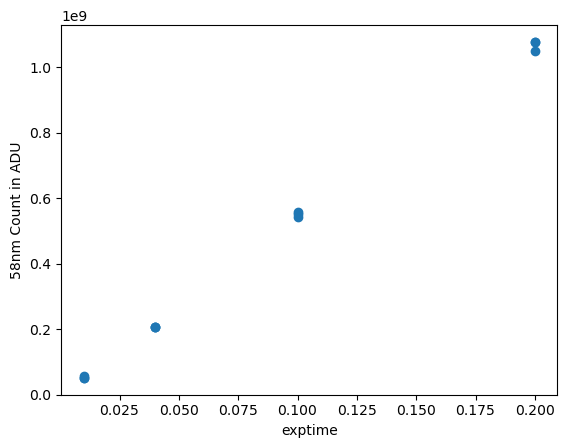

In [5]:

rows = []
for afile in glob.glob("58nm*subdark.fit"):
    rows.append(takestat(afile))
table = Table(rows=rows,names=("exptime","count")) 
pylab.xlabel("exptime")
pylab.ylabel("58nm Count in ADU")
pylab.plot(table["exptime"],table["count"],"o")

print(table["exptime"])
print(table["count"])
#5.236e+09 x - 3.279e+06


RMSE= 11150571.13144152
z1= [ 5.36875049e+09 -4.30593702e+04]
拟合后的公式是：
p1= 
5.369e+09 x - 4.306e+04± 11150571.13144152


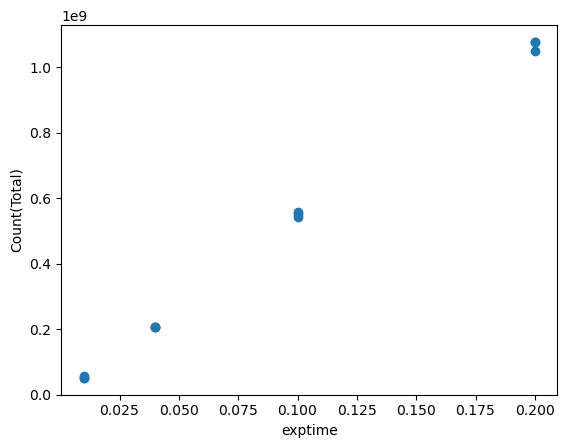

In [6]:
X = table["exptime"]
Y = table["count"]
pylab.xlabel("exptime")
pylab.ylabel("Count(Total)")
pylab.plot(X,Y,"o")

z1 = np.polyfit(X, Y, 1)   ###线性拟合

slope, intercept = z1
y_fit = slope * X + intercept
residuals = Y - y_fit#残差
mse = np.mean(residuals**2)#均方误差
rmse = np.sqrt(mse)#均方根误差
p1 = np.poly1d(z1)
print('RMSE=',rmse)


 

print('z1=',z1)
print("拟合后的公式是：")
#print('p1=',p1)
print("p1=%s± %s" % (p1,rmse))

# z1= [5.19323513e+09 6.23296791e+05]
# 拟合后的公式是：
# p1=  
# 5.193e+09 x + 6.233e+05

# 5.193e+09 x + 6.233e+05± 12601186.693756165

In [7]:
# print('一秒钟内的count数是',5.193e+09  + 6.233e+05)
# print("一秒钟内的count数是+均方根",5.193e+09  + 6.233e+05+ 12601186.693756165)
# print("一秒钟内的count数是-均方根",5.193e+09  + 6.233e+05- 12601186.693756165)


一秒钟内的count数是 5193623300.0
一秒钟内的count数是+均方根 5206224486.693756
一秒钟内的count数是-均方根 5181022113.306244


In [9]:
from uncertainties import ufloat
x = ufloat(5.369e+09 - 4.306e+04,11150571.13144152)
print("一秒钟内的count数是",x)
gain =ufloat(0.0382,0.0011)
electron_num = gain * x
print("一秒钟内的电子数是")
print(f"{electron_num}")  

photo_num= ufloat(213882422.2,2059490.02)

QE=electron_num / photo_num
print(QE)

一秒钟内的count数是 (5.369+/-0.011)e+09
一秒钟内的电子数是
(2.05+/-0.06)e+08
0.959+/-0.029
